# Comparativa TensorFlow vs PyTorch

Notebook reconstruido para comparar metricas de los modelos entrenados.


In [1]:
import time
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_auc_score, roc_curve


In [2]:
# Paths
DATA_DIR = Path("../data/processed/classification_split")
TF_MODEL_PATH = Path("../models/classification/modelo_clasificador.h5")
PT_STATE_PATH = Path("../models/classification/pytorch_mobilenetv2.pth")
PT_FULL_PATH = Path("../models/classification/pytorch_mobilenetv2_full.pt")
OUT_DIR = Path("../models/classification")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR.resolve())
print("TF_MODEL_PATH exists:", TF_MODEL_PATH.exists())
print("PT_STATE_PATH exists:", PT_STATE_PATH.exists())
print("PT_FULL_PATH exists:", PT_FULL_PATH.exists())


DATA_DIR: D:\Universidad\Tesis\Proyecto\TesisFrijol\data\processed\classification_split
TF_MODEL_PATH exists: True
PT_STATE_PATH exists: True
PT_FULL_PATH exists: True


In [3]:
# TensorFlow data generators (binary)
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    rotation_range=15,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.10,
    horizontal_flip=True,
)
val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR / "train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
)
val_gen = val_datagen.flow_from_directory(
    DATA_DIR / "val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
)
test_gen = test_datagen.flow_from_directory(
    DATA_DIR / "test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
)


Found 1928 images belonging to 2 classes.
Found 422 images belonging to 2 classes.
Found 419 images belonging to 2 classes.


In [4]:
# Load TensorFlow model
tf_model = None
if TF_MODEL_PATH.exists():
    tf_model = tf.keras.models.load_model(TF_MODEL_PATH)
    print("Loaded TensorFlow model")
else:
    print("TensorFlow model not found")


Loaded TensorFlow model


In [5]:
# PyTorch dataset and dataloader
pt_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch device:", pt_device)

pt_eval_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

pt_test_ds = datasets.ImageFolder(DATA_DIR / "test", transform=pt_eval_tfms)
pt_test_dl = DataLoader(
    pt_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available()
)
print("Classes (PT):", pt_test_ds.classes)


PyTorch device: cpu
Classes (PT): ['mosaico_dorado', 'sano']


In [6]:
# Load PyTorch model
pt_model = None
if PT_FULL_PATH.exists():
    pt_model = torch.load(PT_FULL_PATH, map_location=pt_device, weights_only=False)
    pt_model.eval()
    print("Loaded PyTorch full model (weights_only=False)")
elif PT_STATE_PATH.exists():
    base = models.mobilenet_v2(weights=None)
    base.classifier = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(base.last_channel, 128),
        nn.SiLU(),
        nn.Dropout(0.2),
        nn.Linear(128, 1),
    )
    base.load_state_dict(torch.load(PT_STATE_PATH, map_location=pt_device))
    pt_model = base.to(pt_device)
    pt_model.eval()
    print("Loaded PyTorch state dict")
else:
    print("PyTorch model not found")


Loaded PyTorch full model (weights_only=False)


In [7]:
# Helpers for metrics and plots
def compute_extra_metrics(y_true, y_pred, average="binary"):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average=average, zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred)
    return precision, recall, f1, cm

def compute_auc(y_true, y_score):
    try:
        return roc_auc_score(y_true, y_score)
    except Exception:
        return float("nan")

def plot_confusion_matrix(cm, labels, title, out_path):
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    fig.savefig(out_path, dpi=220)
    plt.close(fig)

def plot_roc_curve(y_true, y_score, title, out_path):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.plot(fpr, tpr, label="ROC")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
    ax.set_title(title)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()
    fig.tight_layout()
    fig.savefig(out_path, dpi=220)
    plt.close(fig)

def plot_metric_bars(metrics, out_path):
    names = list(metrics.keys())
    acc = [metrics[n]["accuracy"] for n in names]
    f1 = [metrics[n]["f1"] for n in names]
    auc = [metrics[n]["auc"] for n in names]
    x = np.arange(len(names))
    width = 0.25
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.bar(x - width, acc, width, label="Accuracy", color="#4C78A8")
    ax.bar(x, f1, width, label="F1", color="#F58518")
    ax.bar(x + width, auc, width, label="AUC", color="#54A24B")
    ax.set_xticks(x)
    ax.set_xticklabels([n.title() for n in names])
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.set_title("TensorFlow vs PyTorch: Metric Comparison")
    ax.legend(loc="lower right")
    fig.tight_layout()
    fig.savefig(out_path, dpi=220)
    plt.close(fig)

def plot_precision_recall_bars(metrics, out_path):
    names = list(metrics.keys())
    precision = [metrics[n]["precision"] for n in names]
    recall = [metrics[n]["recall"] for n in names]
    f1 = [metrics[n]["f1"] for n in names]
    x = np.arange(len(names))
    width = 0.25
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.bar(x - width, precision, width, label="Precision", color="#9C755F")
    ax.bar(x, recall, width, label="Recall", color="#59A14F")
    ax.bar(x + width, f1, width, label="F1", color="#F28E2B")
    ax.set_xticks(x)
    ax.set_xticklabels([n.title() for n in names])
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.set_title("TensorFlow vs PyTorch: Precision/Recall/F1")
    ax.legend(loc="lower right")
    fig.tight_layout()
    fig.savefig(out_path, dpi=220)
    plt.close(fig)

def plot_latency_bars(metrics, out_path):
    names = list(metrics.keys())
    vals = [metrics[n].get("ms_per_image", float("nan")) for n in names]
    if all(np.isnan(v) for v in vals):
        return
    x = np.arange(len(names))
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(6, 4.0))
    ax.bar(x, vals, color="#4C78A8")
    ax.set_xticks(x)
    ax.set_xticklabels([n.title() for n in names])
    ax.set_ylabel("ms per image")
    ax.set_title("TensorFlow vs PyTorch: Inference Latency")
    fig.tight_layout()
    fig.savefig(out_path, dpi=220)
    plt.close(fig)

def plot_vram_bars(metrics, out_path):
    names = list(metrics.keys())
    vals = [metrics[n].get("vram_peak_bytes", 0) for n in names]
    if all(v == 0 for v in vals):
        return
    x = np.arange(len(names))
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(6, 4.0))
    ax.bar(x, vals, color="#E15759")
    ax.set_xticks(x)
    ax.set_xticklabels([n.title() for n in names])
    ax.set_ylabel("Bytes")
    ax.set_title("TensorFlow vs PyTorch: Peak VRAM")
    fig.tight_layout()
    fig.savefig(out_path, dpi=220)
    plt.close(fig)

def plot_combined_roc(curves, out_path):
    fig, ax = plt.subplots(figsize=(5, 4.2))
    for label, y_true, y_score in curves:
        fpr, tpr, _ = roc_curve(y_true, y_score)
        ax.plot(fpr, tpr, label=label)
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
    ax.set_title("TensorFlow vs PyTorch: ROC Comparison")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()
    fig.tight_layout()
    fig.savefig(out_path, dpi=220)
    plt.close(fig)


## Descripcion de graficos
- Matriz de confusion: conteos de verdaderos positivos/negativos y falsos positivos/negativos.
- Curva ROC: tasa de verdaderos positivos vs falsos positivos para distintos umbrales.
- Barras Accuracy/F1/AUC: comparacion global de desempeno entre frameworks.
- Barras Precision/Recall/F1: calidad de prediccion para la clase positiva.
- Barras de latencia: milisegundos promedio por imagen en el set de test.
- Barras de VRAM pico: memoria maxima de GPU usada durante inferencia (bytes).
- ROC comparativa: ambas curvas ROC en un solo grafico.


In [8]:
# Evaluacion TensorFlow
results = {}
tf_curve = None

if tf_model is not None:
    test_gen.reset()
    tf_raw = tf_model.predict(test_gen, verbose=0)
    tf_probs = tf_raw.reshape(-1)
    tf_y_true = test_gen.classes
    tf_y_pred = (tf_probs > 0.5).astype(int)
    tf_curve = (tf_y_true, tf_probs)
    tf_acc = float((tf_y_pred == tf_y_true).mean())
    p, r, f1, cm = compute_extra_metrics(tf_y_true, tf_y_pred, average="binary")
    auc = compute_auc(tf_y_true, tf_probs)
    results["tensorflow"] = {
        "accuracy": tf_acc,
        "precision": p,
        "recall": r,
        "f1": f1,
        "auc": auc,
        "confusion_matrix": cm.tolist(),
    }

    plot_confusion_matrix(cm, ["sano", "mosaico"], "TensorFlow Confusion Matrix", OUT_DIR / "confusion_tensorflow.png")
    plot_roc_curve(tf_y_true, tf_probs, "TensorFlow ROC", OUT_DIR / "roc_tensorflow.png")

    # Inference time per image
    for _ in range(2):
        batch = next(test_gen)
        batch_x = batch[0] if isinstance(batch, (tuple, list)) else batch
        _ = tf_model.predict(batch_x, verbose=0)
    test_gen.reset()
    start = time.time()
    for _ in range(len(test_gen)):
        batch = next(test_gen)
        batch_x = batch[0] if isinstance(batch, (tuple, list)) else batch
        _ = tf_model.predict(batch_x, verbose=0)
    elapsed = time.time() - start
    results["tensorflow"]["ms_per_image"] = (elapsed / max(1, test_gen.n)) * 1000.0

    # GPU memory (if available)
    try:
        info = tf.config.experimental.get_memory_info("GPU:0")
        results["tensorflow"]["vram_current_bytes"] = int(info.get("current", 0))
        results["tensorflow"]["vram_peak_bytes"] = int(info.get("peak", 0))
    except Exception:
        pass

    print("TensorFlow metrics:", results["tensorflow"])
else:
    print("TensorFlow model not available")


TensorFlow metrics: {'accuracy': 0.9952267303102625, 'precision': 0.991701244813278, 'recall': 1.0, 'f1': 0.9958333333333333, 'auc': 0.999953509995351, 'confusion_matrix': [[178, 2], [0, 239]], 'ms_per_image': 48.7030832750416}


In [9]:
# Evaluacion PyTorch
pt_curve = None
if pt_model is not None:
    pt_model.eval()
    correct = 0
    total = 0
    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in pt_test_dl:
            xb = xb.to(pt_device)
            yb = yb.to(pt_device).float()
            out = pt_model(xb).squeeze(1)
            probs = torch.sigmoid(out)
            preds = (probs > 0.5).long()
            correct += (preds == yb.long()).sum().item()
            total += yb.size(0)
            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(yb.long().cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)
    y_prob = np.concatenate(all_probs)
    pt_curve = (y_true, y_prob)

    acc = correct / max(1, total)
    p, r, f1, cm = compute_extra_metrics(y_true, y_pred, average="binary")
    auc = compute_auc(y_true, y_prob)
    results["pytorch"] = {
        "accuracy": acc,
        "precision": p,
        "recall": r,
        "f1": f1,
        "auc": auc,
        "confusion_matrix": cm.tolist(),
    }

    plot_confusion_matrix(cm, ["sano", "mosaico"], "PyTorch Confusion Matrix", OUT_DIR / "confusion_pytorch.png")
    plot_roc_curve(y_true, y_prob, "PyTorch ROC", OUT_DIR / "roc_pytorch.png")

    # Inference time per image
    it = iter(pt_test_dl)
    xb, _ = next(it)
    xb = xb.to(pt_device)
    with torch.no_grad():
        for _ in range(10):
            _ = pt_model(xb).squeeze(1)
    if pt_device.type == "cuda":
        torch.cuda.synchronize()
    start = time.time()
    with torch.no_grad():
        for xb, _ in pt_test_dl:
            xb = xb.to(pt_device)
            _ = pt_model(xb).squeeze(1)
    if pt_device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.time() - start
    results["pytorch"]["ms_per_image"] = (elapsed / max(1, len(pt_test_dl.dataset))) * 1000.0

    if pt_device.type == "cuda":
        results["pytorch"]["vram_peak_bytes"] = int(torch.cuda.max_memory_allocated())

    print("PyTorch metrics:", results["pytorch"])
else:
    print("PyTorch model not available")


PyTorch metrics: {'accuracy': 0.9880668257756563, 'precision': 0.9795081967213115, 'recall': 1.0, 'f1': 0.989648033126294, 'auc': 1.0, 'confusion_matrix': [[175, 5], [0, 239]], 'ms_per_image': 53.72446249094669}


In [10]:
# Save metrics and plots
if results:
    plot_metric_bars(results, OUT_DIR / "compare_metrics.png")
    plot_precision_recall_bars(results, OUT_DIR / "compare_metrics_prf.png")
    plot_latency_bars(results, OUT_DIR / "compare_latency.png")
    plot_vram_bars(results, OUT_DIR / "compare_vram.png")
    try:
        curves = []
        if tf_curve is not None:
            curves.append(("TensorFlow", tf_curve[0], tf_curve[1]))
        if pt_curve is not None:
            curves.append(("PyTorch", pt_curve[0], pt_curve[1]))
        if len(curves) >= 2:
            plot_combined_roc(curves, OUT_DIR / "roc_compare.png")
    except Exception:
        pass

    metrics_path = OUT_DIR / "compare_metrics.json"
    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(results, f, ensure_ascii=False, indent=2)
    print("Saved metrics JSON:", metrics_path)

    csv_path = OUT_DIR / "compare_metrics.csv"
    with open(csv_path, "w", encoding="utf-8") as f:
        f.write("framework,accuracy,precision,recall,f1,auc,ms_per_image,vram_peak_bytes\n")
        for name, vals in results.items():
            f.write(
                f"{name},"
                f"{vals['accuracy']:.6f},"
                f"{vals['precision']:.6f},"
                f"{vals['recall']:.6f},"
                f"{vals['f1']:.6f},"
                f"{vals.get('auc', float('nan')):.6f},"
                f"{vals.get('ms_per_image', float('nan')):.6f},"
                f"{vals.get('vram_peak_bytes', 0)}\n"
            )
    print("Saved metrics CSV:", csv_path)
else:
    print("No results to save")


Saved metrics JSON: ..\models\classification\compare_metrics.json
Saved metrics CSV: ..\models\classification\compare_metrics.csv


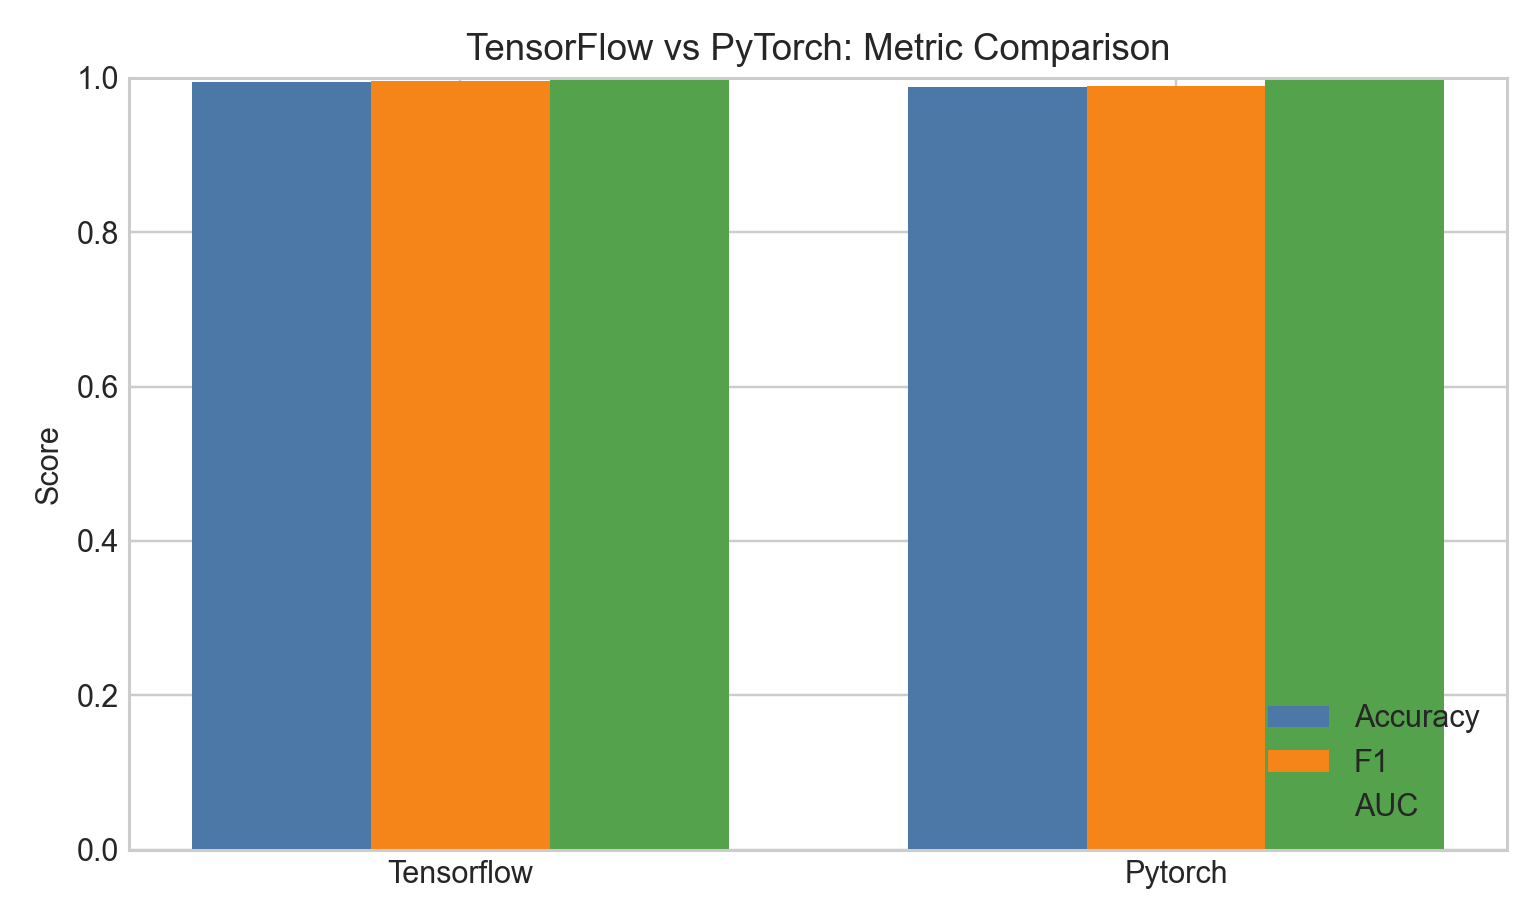

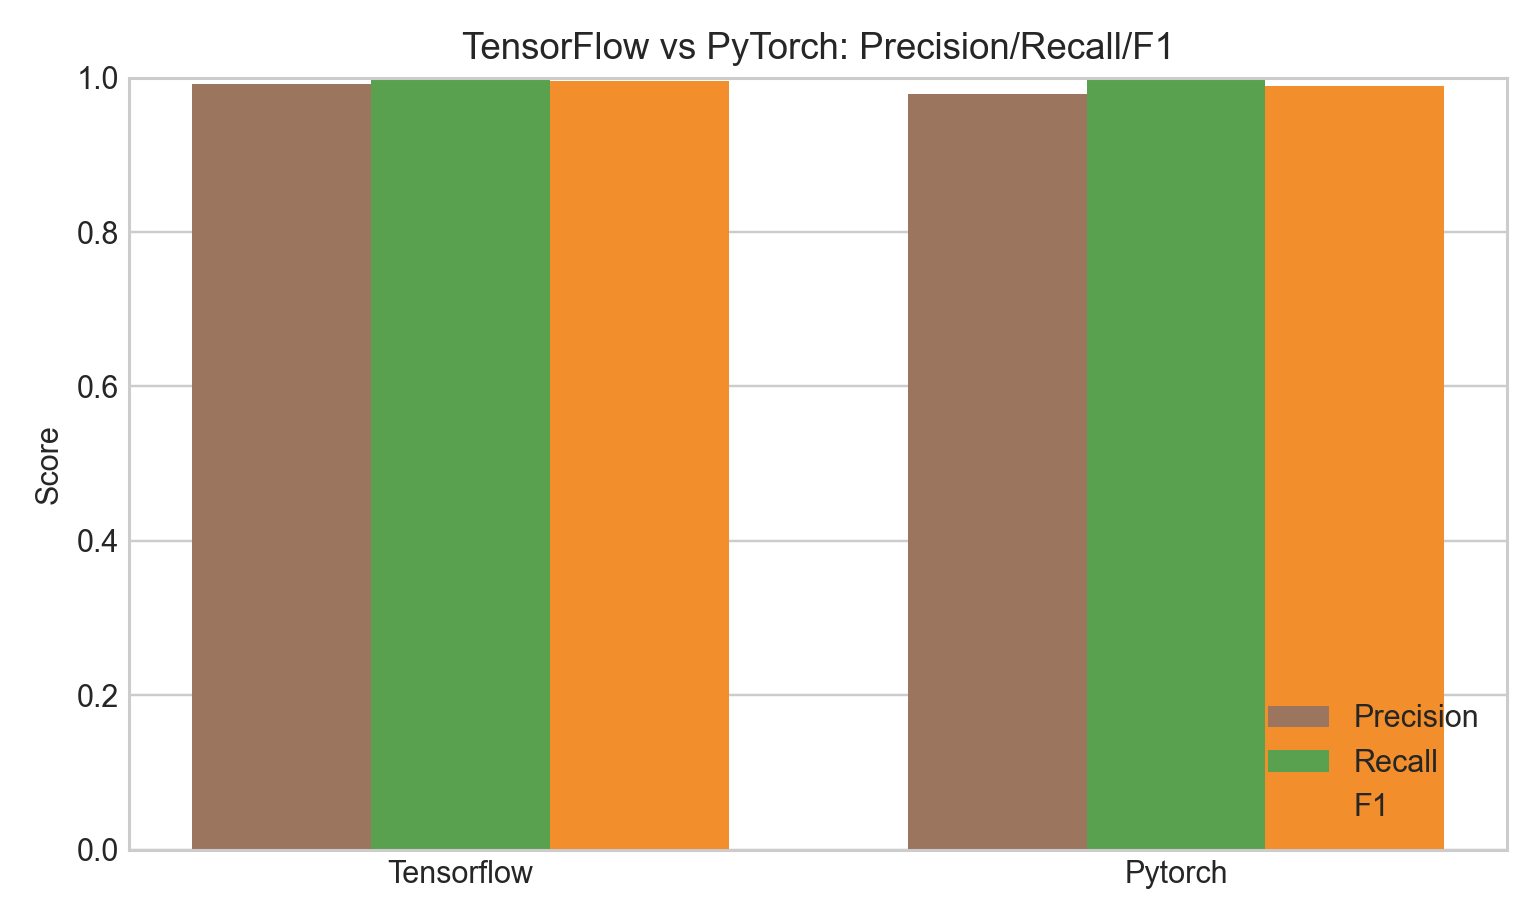

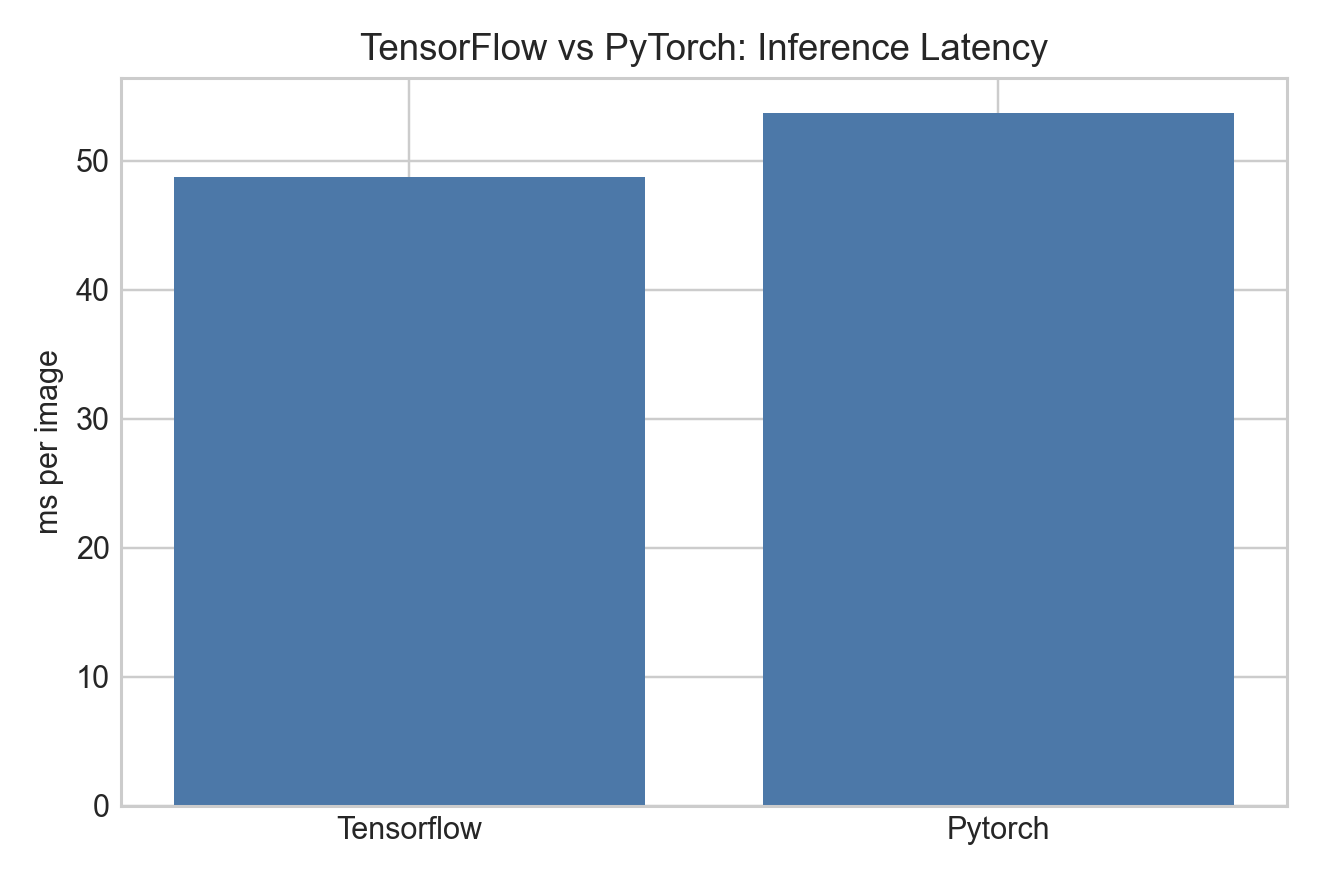

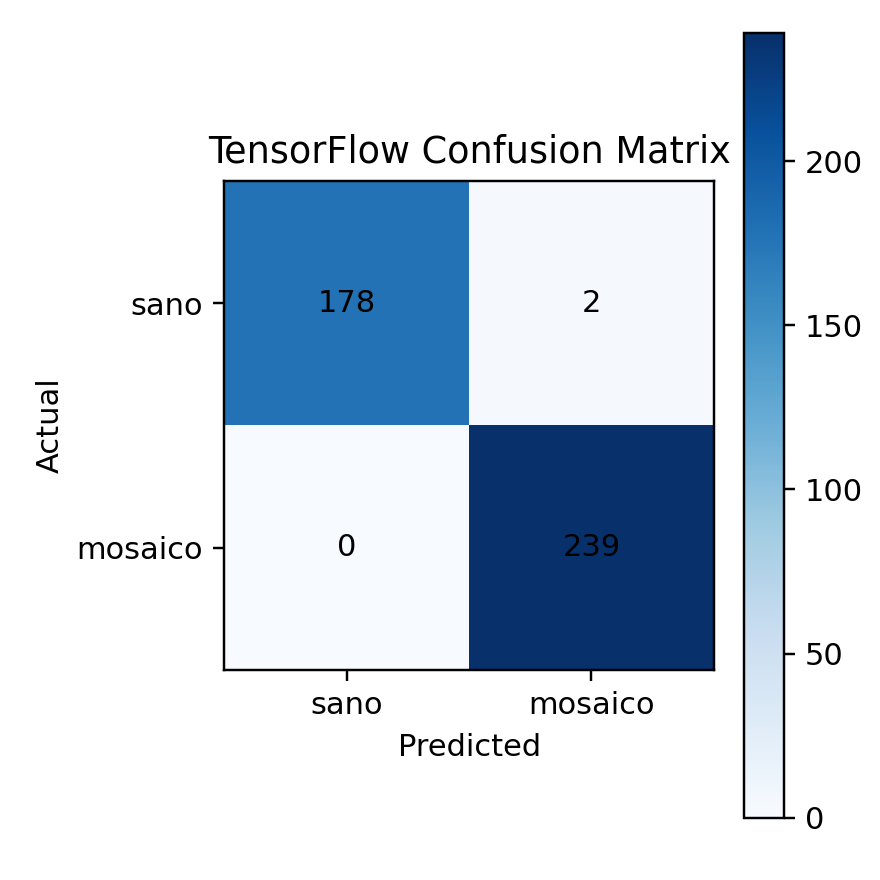

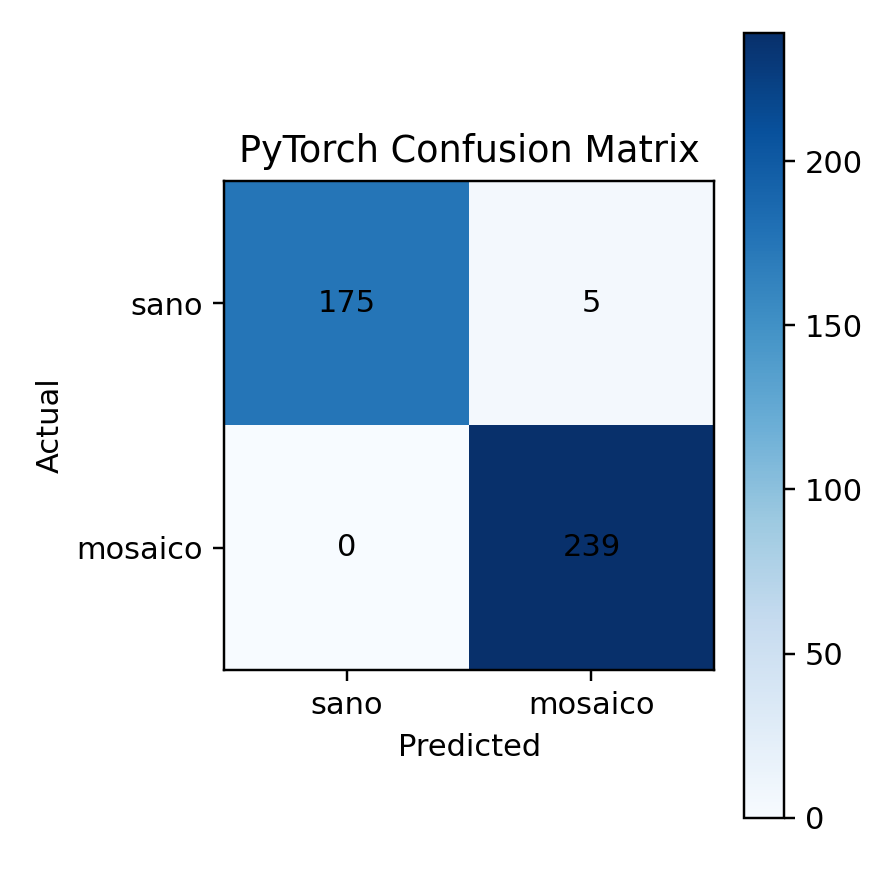

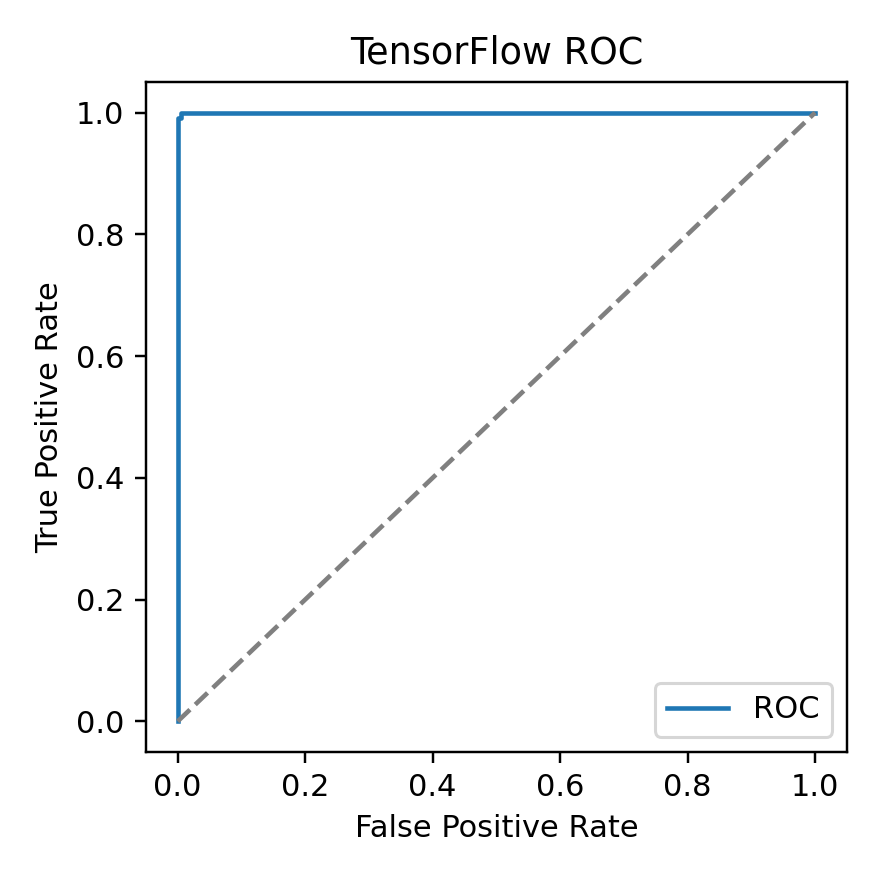

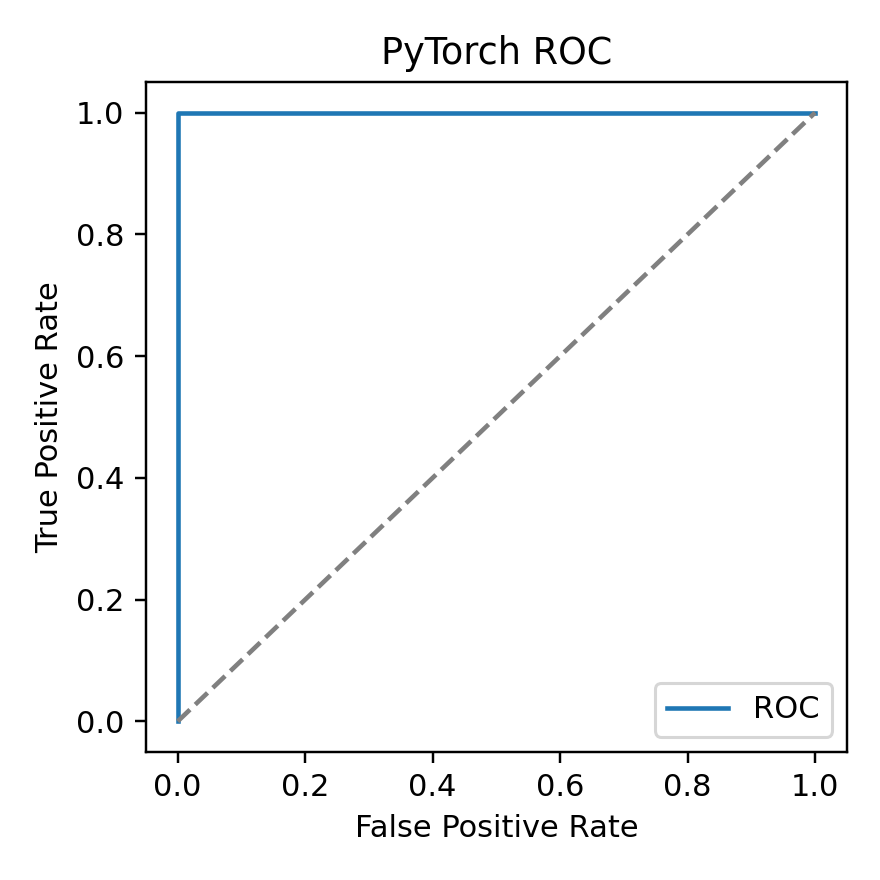

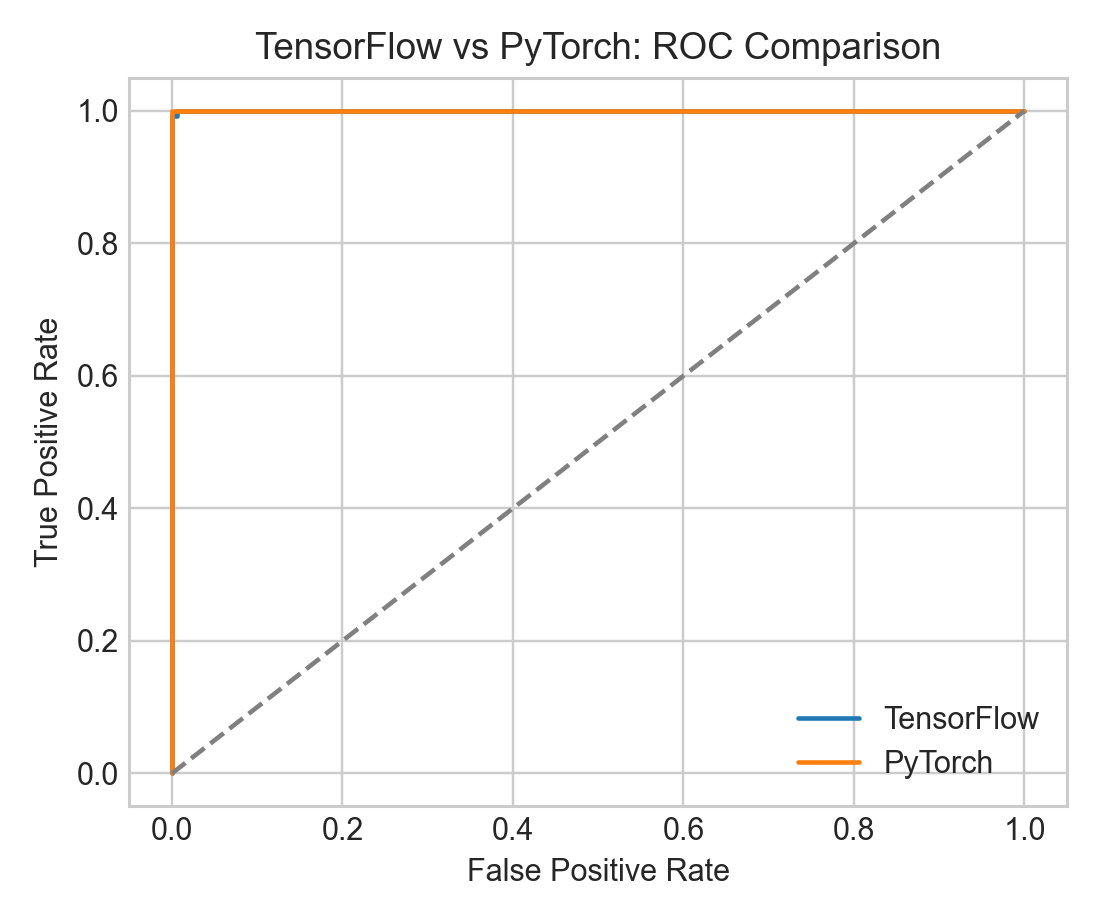

In [11]:
# Display plots
from IPython.display import Image, display

if (OUT_DIR / "compare_metrics.png").exists():
    display(Image(filename=str(OUT_DIR / "compare_metrics.png")))
if (OUT_DIR / "compare_metrics_prf.png").exists():
    display(Image(filename=str(OUT_DIR / "compare_metrics_prf.png")))
if (OUT_DIR / "compare_latency.png").exists():
    display(Image(filename=str(OUT_DIR / "compare_latency.png")))
if (OUT_DIR / "compare_vram.png").exists():
    display(Image(filename=str(OUT_DIR / "compare_vram.png")))
if (OUT_DIR / "confusion_tensorflow.png").exists():
    display(Image(filename=str(OUT_DIR / "confusion_tensorflow.png")))
if (OUT_DIR / "confusion_pytorch.png").exists():
    display(Image(filename=str(OUT_DIR / "confusion_pytorch.png")))
if (OUT_DIR / "roc_tensorflow.png").exists():
    display(Image(filename=str(OUT_DIR / "roc_tensorflow.png")))
if (OUT_DIR / "roc_pytorch.png").exists():
    display(Image(filename=str(OUT_DIR / "roc_pytorch.png")))
if (OUT_DIR / "roc_compare.png").exists():
    display(Image(filename=str(OUT_DIR / "roc_compare.png")))
